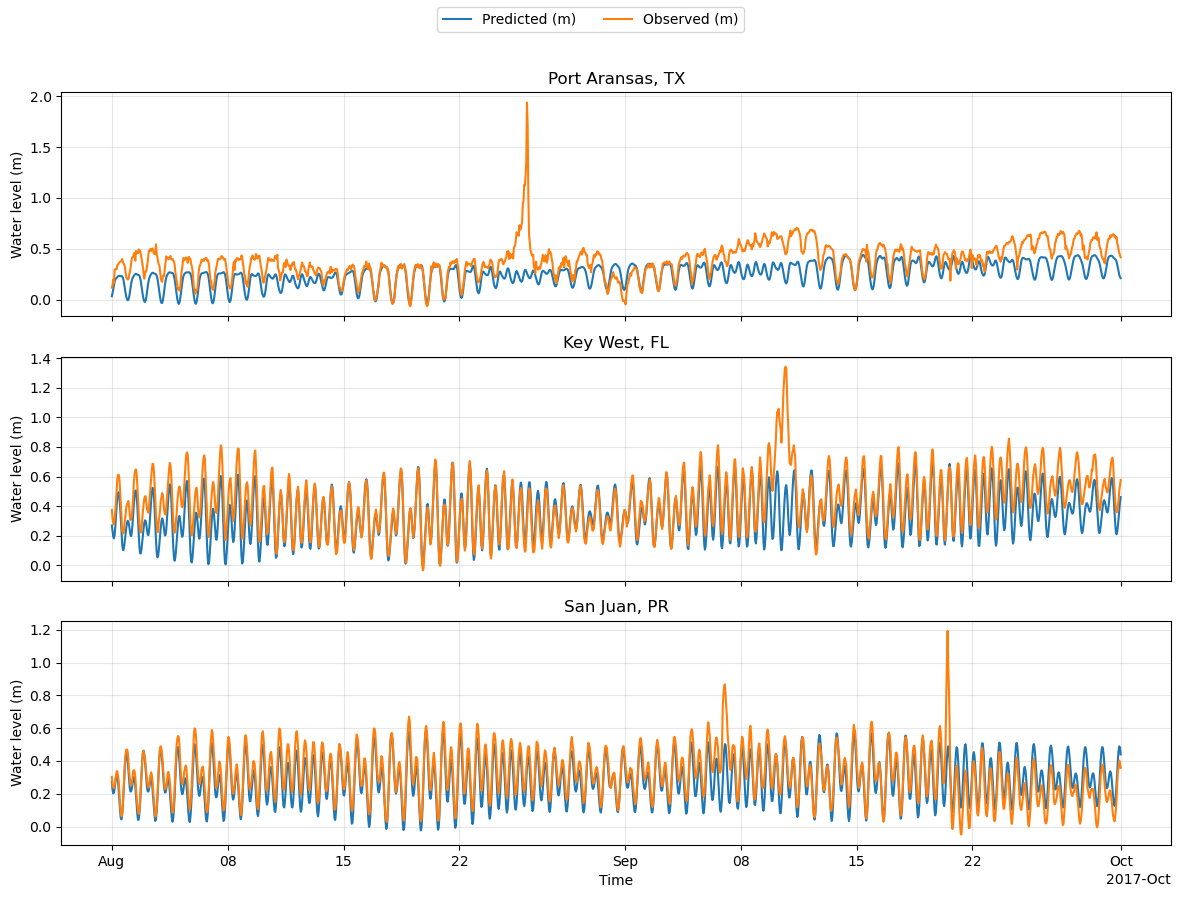

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ------------------ FILE PATHS ------------------
files = {
    "Port Aransas, TX": r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-2\CO-OPS_8775237_met.csv",
    "Key West, FL":     r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-2\CO-OPS_8724580_met.csv",
    "San Juan, PR":     r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-2\CO-OPS_9755371_met.csv",
}

# ------------------ COLUMN NAMES ------------------
TIME_COL = "Time"
PRED_COL = "Predicted (m)"
OBS_COL  = "Verified (m)"

# ------------------ READ FUNCTION ------------------
def read_noaa_csv(path):
    df = pd.read_csv(path)

    # Convert columns
    df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
    df[PRED_COL] = pd.to_numeric(df[PRED_COL], errors="coerce")
    df[OBS_COL]  = pd.to_numeric(df[OBS_COL],  errors="coerce")

    # Keep only required columns
    df = df[[TIME_COL, PRED_COL, OBS_COL]].dropna(subset=[TIME_COL])
    df = df.sort_values(TIME_COL)

    return df

# ------------------ LOAD DATA ------------------
data = {name: read_noaa_csv(path) for name, path in files.items()}

# Optional: use common time window
tmin = max(df[TIME_COL].min() for df in data.values())
tmax = min(df[TIME_COL].max() for df in data.values())

for k in data:
    data[k] = data[k][(data[k][TIME_COL] >= tmin) & (data[k][TIME_COL] <= tmax)]

# ------------------ PLOT ------------------
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

for ax, (station, df) in zip(axes, data.items()):
    ax.plot(df[TIME_COL], df[PRED_COL], label="Predicted (m)")
    ax.plot(df[TIME_COL], df[OBS_COL], label="Observed (m)")
    ax.set_title(station)
    ax.set_ylabel("Water level (m)")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time")
axes[-1].xaxis.set_major_locator(mdates.AutoDateLocator())
axes[-1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)

fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


In [3]:
import pandas as pd

# ------------------ FILE PATHS ------------------
files = {
    "Port Aransas, TX": r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-2\CO-OPS_8775237_met.csv",
    "Key West, FL":     r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-2\CO-OPS_8724580_met.csv",
    "San Juan, PR":     r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-2\CO-OPS_9755371_met.csv",
}

# ------------------ COLUMN NAMES ------------------
TIME_COL = "Time"
PRED_COL = "Predicted (m)"
OBS_COL  = "Verified (m)"

# ------------------ READ FUNCTION ------------------
def read_noaa_csv(path):
    df = pd.read_csv(path)

    df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
    df[PRED_COL] = pd.to_numeric(df[PRED_COL], errors="coerce")
    df[OBS_COL]  = pd.to_numeric(df[OBS_COL], errors="coerce")

    df = df[[TIME_COL, PRED_COL, OBS_COL]].dropna(subset=[TIME_COL])
    df = df.sort_values(TIME_COL)

    return df

# ------------------ ANALYSIS ------------------
results = []

for station, path in files.items():
    df = read_noaa_csv(path)

    # Maximums
    max_obs_row = df.loc[df[OBS_COL].idxmax()]
    max_pred_row = df.loc[df[PRED_COL].idxmax()]

    # Minimums
    min_obs_row = df.loc[df[OBS_COL].idxmin()]
    min_pred_row = df.loc[df[PRED_COL].idxmin()]

    results.append({
        "Station": station,

        "Max Observed (m)": max_obs_row[OBS_COL],
        "Time Max Observed": max_obs_row[TIME_COL],

        "Max Predicted (m)": max_pred_row[PRED_COL],
        "Time Max Predicted": max_pred_row[TIME_COL],

        "Min Observed (m)": min_obs_row[OBS_COL],
        "Time Min Observed": min_obs_row[TIME_COL],

        "Min Predicted (m)": min_pred_row[PRED_COL],
        "Time Min Predicted": min_pred_row[TIME_COL],
    })

# ------------------ OUTPUT ------------------
summary_df = pd.DataFrame(results)

# Pretty print
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
print(summary_df)


            Station  Max Observed (m)   Time Max Observed  Max Predicted (m)  Time Max Predicted  Min Observed (m)   Time Min Observed  Min Predicted (m)  \
0  Port Aransas, TX             1.937 2017-08-26 02:00:00              0.440 2017-09-15 09:00:00            -0.063 2017-08-19 01:00:00             -0.046   
1      Key West, FL             1.342 2017-09-10 17:00:00              0.703 2017-09-18 13:00:00            -0.034 2017-08-19 19:00:00             -0.002   
2      San Juan, PR             1.193 2017-09-20 12:00:00              0.580 2017-08-20 00:00:00            -0.049 2017-09-21 08:00:00             -0.024   

   Time Min Predicted  
0 2017-08-19 00:00:00  
1 2017-08-19 19:00:00  
2 2017-08-19 16:00:00  


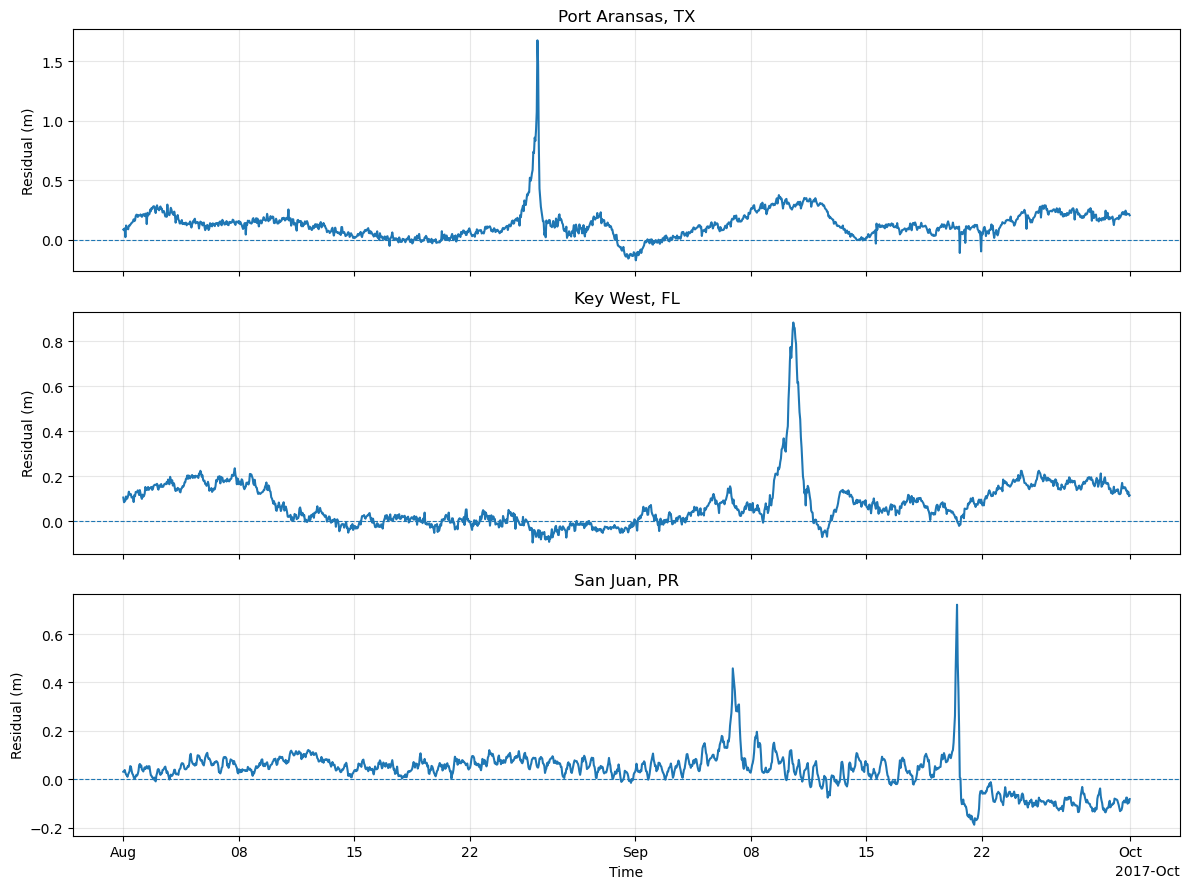

            Station  Max Residual (m)   Time Max Residual  Min Residual (m)   Time Min Residual
0  Port Aransas, TX             1.676 2017-08-26 02:00:00            -0.175 2017-09-01 01:00:00
1      Key West, FL             0.884 2017-09-10 14:00:00            -0.094 2017-08-25 19:00:00
2      San Juan, PR             0.721 2017-09-20 12:00:00            -0.188 2017-09-21 13:00:00


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ------------------ FILE PATHS ------------------
files = {
    "Port Aransas, TX": r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-2\CO-OPS_8775237_met.csv",
    "Key West, FL":     r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-2\CO-OPS_8724580_met.csv",
    "San Juan, PR":     r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-2\CO-OPS_9755371_met.csv",
}

# ------------------ COLUMN NAMES ------------------
TIME_COL = "Time"
PRED_COL = "Predicted (m)"
OBS_COL  = "Verified (m)"

# ------------------ READ FUNCTION ------------------
def read_noaa_csv(path):
    df = pd.read_csv(path)

    df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
    df[PRED_COL] = pd.to_numeric(df[PRED_COL], errors="coerce")
    df[OBS_COL]  = pd.to_numeric(df[OBS_COL], errors="coerce")

    df = df[[TIME_COL, PRED_COL, OBS_COL]].dropna(subset=[TIME_COL])
    df = df.sort_values(TIME_COL)

    return df

# ------------------ PROCESS DATA ------------------
data = {}
for station, path in files.items():
    df = read_noaa_csv(path)
    df["Residual (m)"] = df[OBS_COL] - df[PRED_COL]
    data[station] = df

# ------------------ FIND COMMON TIME WINDOW (optional but clean) ------------------
tmin = max(df[TIME_COL].min() for df in data.values())
tmax = min(df[TIME_COL].max() for df in data.values())

for k in data:
    data[k] = data[k][
        (data[k][TIME_COL] >= tmin) &
        (data[k][TIME_COL] <= tmax)
    ]

# ------------------ PLOT RESIDUALS ------------------
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

for ax, (station, df) in zip(axes, data.items()):
    ax.plot(df[TIME_COL], df["Residual (m)"])
    ax.axhline(0, linestyle="--", linewidth=0.8)
    ax.set_title(station)
    ax.set_ylabel("Residual (m)")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time")
axes[-1].xaxis.set_major_locator(mdates.AutoDateLocator())
axes[-1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))

fig.tight_layout()
plt.show()

# ------------------ MIN / MAX RESIDUALS ------------------
results = []

for station, df in data.items():
    max_row = df.loc[df["Residual (m)"].idxmax()]
    min_row = df.loc[df["Residual (m)"].idxmin()]

    results.append({
        "Station": station,
        "Max Residual (m)": max_row["Residual (m)"],
        "Time Max Residual": max_row[TIME_COL],
        "Min Residual (m)": min_row["Residual (m)"],
        "Time Min Residual": min_row[TIME_COL],
    })

summary = pd.DataFrame(results)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
print(summary)


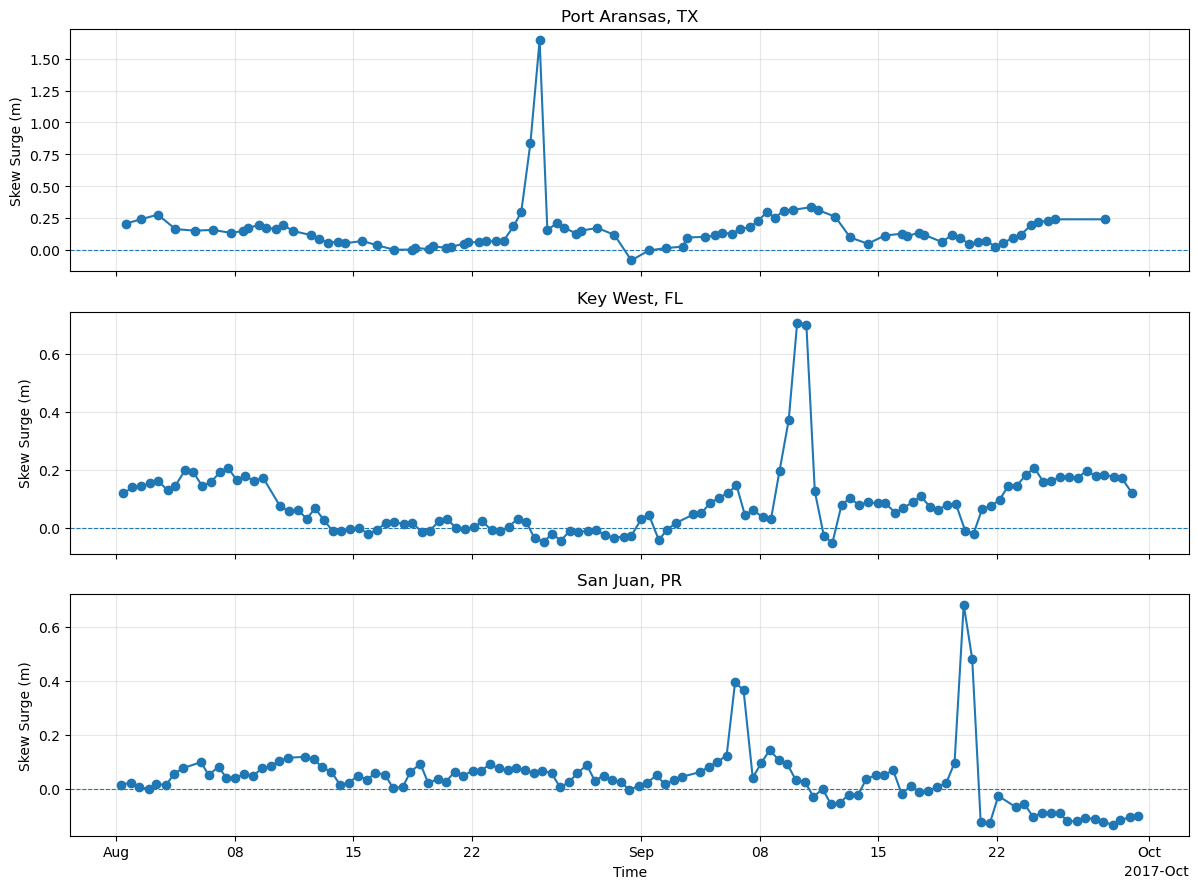

            Station  Max Skew Surge (m)            Time Max  Min Skew Surge (m)            Time Min
0  Port Aransas, TX               1.644 2017-08-26 00:00:00              -0.083 2017-08-31 10:00:00
1      Key West, FL               0.707 2017-09-10 05:00:00              -0.051 2017-09-12 07:00:00
2      San Juan, PR               0.682 2017-09-20 01:00:00              -0.134 2017-09-28 20:00:00


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ------------------ FILE PATHS ------------------
files = {
    "Port Aransas, TX": r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-2\CO-OPS_8775237_met.csv",
    "Key West, FL":     r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-2\CO-OPS_8724580_met.csv",
    "San Juan, PR":     r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-2\CO-OPS_9755371_met.csv",
}

# ------------------ COLUMN NAMES ------------------
TIME_COL = "Time"
PRED_COL = "Predicted (m)"
OBS_COL  = "Verified (m)"

# ------------------ READ FUNCTION ------------------
def read_noaa_csv(path):
    df = pd.read_csv(path)
    df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
    df[PRED_COL] = pd.to_numeric(df[PRED_COL], errors="coerce")
    df[OBS_COL]  = pd.to_numeric(df[OBS_COL],  errors="coerce")
    df = df[[TIME_COL, PRED_COL, OBS_COL]].dropna()
    df = df.sort_values(TIME_COL)
    return df

# ------------------ SKEW SURGE FUNCTION ------------------
def compute_skew_surge(df):
    """
    Compute skew surge following the standard definition:
    max(observed) - max(predicted) per tidal cycle
    """
    df = df.copy()

    # Identify predicted high tides
    df["Pred_High"] = (
        (df[PRED_COL] > df[PRED_COL].shift(1)) &
        (df[PRED_COL] > df[PRED_COL].shift(-1))
    )

    high_tides = df[df["Pred_High"]].reset_index(drop=True)

    skew_records = []

    for i in range(len(high_tides) - 1):
        t_start = high_tides.loc[i, TIME_COL]
        t_end   = high_tides.loc[i + 1, TIME_COL]

        cycle = df[(df[TIME_COL] >= t_start) & (df[TIME_COL] < t_end)]
        if cycle.empty:
            continue

        max_obs = cycle[OBS_COL].max()
        max_pred = cycle[PRED_COL].max()

        skew_records.append({
            "Time": t_start,
            "Skew Surge (m)": max_obs - max_pred
        })

    return pd.DataFrame(skew_records)

# ------------------ PROCESS AND PLOT ------------------
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
results = []

for ax, (station, path) in zip(axes, files.items()):
    df = read_noaa_csv(path)
    skew_df = compute_skew_surge(df)

    ax.plot(skew_df["Time"], skew_df["Skew Surge (m)"], marker="o", linestyle="-")
    ax.axhline(0, linestyle="--", linewidth=0.8)
    ax.set_title(station)
    ax.set_ylabel("Skew Surge (m)")
    ax.grid(True, alpha=0.3)

    # Min / Max
    max_row = skew_df.loc[skew_df["Skew Surge (m)"].idxmax()]
    min_row = skew_df.loc[skew_df["Skew Surge (m)"].idxmin()]

    results.append({
        "Station": station,
        "Max Skew Surge (m)": max_row["Skew Surge (m)"],
        "Time Max": max_row["Time"],
        "Min Skew Surge (m)": min_row["Skew Surge (m)"],
        "Time Min": min_row["Time"],
    })

axes[-1].set_xlabel("Time")
axes[-1].xaxis.set_major_locator(mdates.AutoDateLocator())
axes[-1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))

plt.tight_layout()
plt.show()

# ------------------ SUMMARY TABLE ------------------
summary = pd.DataFrame(results)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
print(summary)
